### Healthcare Readmission Analytics

#### Notebook 06 — Model Improvement & Hyperparameter Tuning

##### Purpose

This notebook improves the baseline machine learning model for hospital readmission prediction.

The goals are:

- validate model performance using cross-validation
- tune Random Forest hyperparameters
- compare baseline and tuned model performance
- save final model results
- identify final key readmission predictors

##### Why This Matters

A baseline model gives a starting point, but model tuning helps improve performance and reduce overfitting.

In healthcare analytics, model reliability is especially important because predictions may influence patient risk prioritization.

Import Libraries

In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

Load Modeling Dataset

In [2]:
# ============================================
# LOAD MODELING DATASET
# ============================================

df = pd.read_csv("../data/processed/modeling_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (101766, 12)


,age_numeric,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,total_utilization,high_medication_count,readmitted_flag
0,5,1,41,0,1,0,0,0,1,0,0,0
1,15,3,59,0,18,0,0,0,9,0,1,1
2,25,2,11,5,13,2,0,1,6,3,0,0
3,35,2,44,1,16,0,0,0,7,0,1,0
4,45,1,51,0,8,0,0,0,5,0,0,0


Define Features and Target

In [3]:
# ============================================
# FEATURES AND TARGET
# ============================================

X = df.drop(columns=["readmitted_flag"])
y = df["readmitted_flag"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (101766, 11)
Target: (101766,)


Train-Test Split

In [4]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (81412, 11)
X_test: (20354, 11)


Baseline Random Forest for Comparison

In [5]:
# ============================================
# BASELINE RANDOM FOREST
# ============================================

baseline_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)

baseline_pred = baseline_rf.predict(X_test)

Evaluation Function

In [6]:
# ============================================
# EVALUATION FUNCTION
# ============================================

def evaluate_model(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred)
    }

Baseline Results

In [7]:
baseline_results = evaluate_model(
    "Baseline Random Forest",
    y_test,
    baseline_pred
)

baseline_results

{'model': 'Baseline Random Forest',
 'accuracy': 0.626019455635256,
 'precision': 0.6198996882201437,
 'recall': 0.4874746828696301,
 'f1_score': 0.5457691848669293}

Cross-Validation

In [8]:
# ============================================
# CROSS VALIDATION
# ============================================

cv_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

print("Cross-validation F1 scores:", cv_scores)
print("Average CV F1:", cv_scores.mean())

Cross-validation F1 scores: [0.53698778 0.54105016 0.54473462]
Average CV F1: 0.5409241878143752


Why Cross-Validation matters:

Cross-validation evaluates the model across multiple data splits.

This gives a more reliable estimate of performance than a single train-test split.

Consequence if Skipped

The model may look good only because of one favorable train-test split.

Hyperparameter Search

In [9]:
# ============================================
# RANDOMIZED SEARCH PARAMETERS
# ============================================

param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [8, 10, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

Run Randomized Search

In [10]:
# ============================================
# RANDOMIZED SEARCH CV
# ============================================

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV F1 Score:")
print(random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 12, 'class_weight': 'balanced'}
Best CV F1 Score:
0.5672103982477466


Tuned Model Evaluation

In [11]:
# ============================================
# TUNED MODEL EVALUATION
# ============================================

best_rf = random_search.best_estimator_

tuned_pred = best_rf.predict(X_test)

tuned_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    tuned_pred
)

tuned_results

{'model': 'Tuned Random Forest',
 'accuracy': 0.6232190232878059,
 'precision': 0.6000467508181393,
 'recall': 0.5472764097644175,
 'f1_score': 0.572448012488153}

Classification Report

In [12]:
print(classification_report(y_test, tuned_pred))

              precision    recall  f1-score   support

           0       0.64      0.69      0.66     10973
           1       0.60      0.55      0.57      9381

    accuracy                           0.62     20354
   macro avg       0.62      0.62      0.62     20354
weighted avg       0.62      0.62      0.62     20354



Compare Baseline vs Tuned

In [13]:
# ============================================
# COMPARE MODELS
# ============================================

comparison_df = pd.DataFrame([
    baseline_results,
    tuned_results
])

comparison_df

,model,accuracy,precision,recall,f1_score
0,Baseline Random Forest,0.626019,0.619900,0.487475,0.545769
1,Tuned Random Forest,0.623219,0.600047,0.547276,0.572448


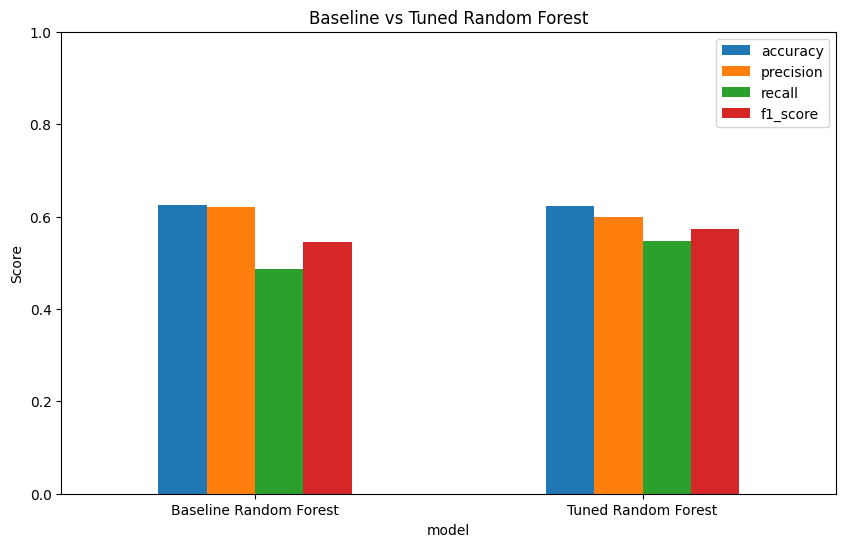

In [14]:
# Chart

comparison_df.set_index("model")[["accuracy", "precision", "recall", "f1_score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Baseline vs Tuned Random Forest")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

Confusion Matrix

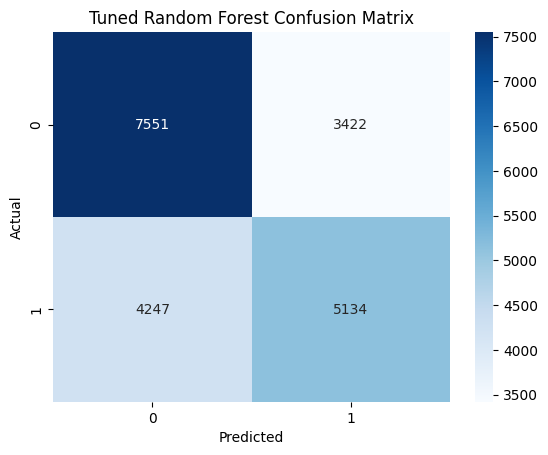

In [15]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, tuned_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Final Feature Importance

In [16]:
# ============================================
# FINAL FEATURE IMPORTANCE
# ============================================

final_feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

final_feature_importance

,feature,importance
9,total_utilization,0.207208
7,number_inpatient,0.160779
2,num_lab_procedures,0.135632
4,num_medications,0.112576
8,number_diagnoses,0.088065
0,age_numeric,0.079598
1,time_in_hospital,0.077800
3,num_procedures,0.055056
6,number_emergency,0.039391
5,number_outpatient,0.033108


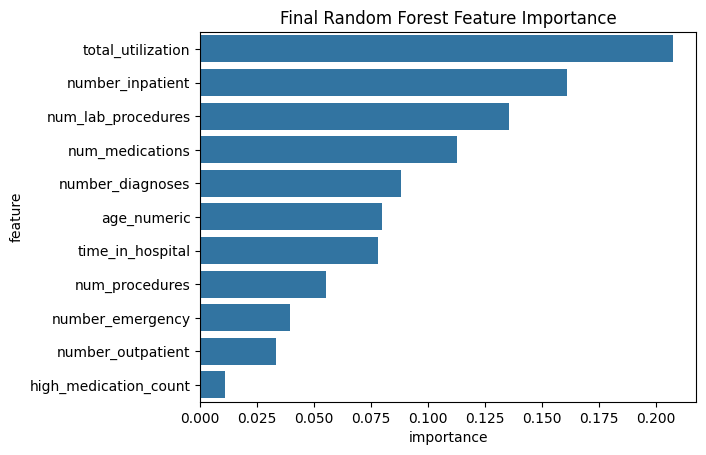

In [17]:
# Chart 

sns.barplot(
    data=final_feature_importance,
    x="importance",
    y="feature"
)

plt.title("Final Random Forest Feature Importance")
plt.show()

Save Final Outputs

In [18]:
# ============================================
# SAVE FINAL OUTPUTS
# ============================================

comparison_df.to_csv(
    "../outputs/tuned_model_comparison.csv",
    index=False
)

final_feature_importance.to_csv(
    "../outputs/final_feature_importance.csv",
    index=False
)

final_predictions = X_test.copy()
final_predictions["actual_readmitted"] = y_test.values
final_predictions["predicted_readmitted"] = tuned_pred

final_predictions.to_csv(
    "../outputs/final_model_predictions.csv",
    index=False
)

joblib.dump(
    best_rf,
    "../models/final_random_forest_model.pkl"
)

print("Final model outputs saved.")

Final model outputs saved.


Baseline vs Tuned Model

| Model       | Accuracy | Precision | Recall | F1 Score |
| ----------- | -------: | --------: | -----: | -------: |
| Baseline RF |   62.60% |    61.99% | 48.75% |   54.58% |
| Tuned RF    |   62.32% |    60.00% | 54.73% |   57.24% |

Most Important Observation

Many beginners only look at accuracy.

A healthcare analyst should focus on:

Recall
F1 Score

because the goal is to identify as many high-risk patients as possible.

Recall Improvement :

Baseline: 48.75%

Tuned: 54.73%

Improvement: +5.98 percentage points

This is significant.

F1 Score Improvement :

Baseline: 54.58%

Tuned: 57.24%

Improvement: +2.66 percentage points

This means the tuned model achieved a better balance between:

- precision
- recall

Healthcare Interpretation:

If a hospital uses this model:

Baseline Model

Would miss more high-risk patients.

Tuned Model

Captures more potentially readmitted patients.

For healthcare use cases:

Higher recall is usually preferable.

Cross Validation Result:

Best CV F1 Score: 0.5672

This is very close to:

Test F1 Score: 0.5724

This is a great sign.

The model performs similarly on:

- Cross Validation
- Test Data

This suggests: Limited overfitting

Hyperparameter Tuning Result:

Best Parameters:

{
 'n_estimators': 150,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_depth': 12,
 'class_weight': 'balanced'
}
Why These Make Sense
class_weight='balanced'

The dataset has:

- 53.9% non-readmitted
- 46.1% readmitted

Balancing helps the model pay more attention to readmitted patients.

max_depth=12 Controls complexity.

Too deep: Overfitting

Too shallow: Underfitting

Depth 12 appears to be a good compromise.

Final Feature Importance 

| Rank | Feature            | Importance |
| ---- | ------------------ | ---------: |
| 1    | total_utilization  |     20.72% |
| 2    | number_inpatient   |     16.08% |
| 3    | num_lab_procedures |     13.56% |
| 4    | num_medications    |     11.26% |
| 5    | number_diagnoses   |      8.81% |

Major Project Finding:

machine learning model confirms the EDA findings.

- Strongest Predictor
- total_utilization

This means:

Patients with greater healthcare usage history are much more likely to be readmitted.

- Second Strongest Predictor
- number_inpatient

This directly supports our earlier analysis where readmission rates increased dramatically with previous inpatient visits.


#### Model Improvement Summary

##### What Was Done

- Random Forest was validated using cross-validation
- Hyperparameters were tuned using RandomizedSearchCV
- Baseline and tuned models were compared
- Final feature importance was generated
- Final model outputs were saved

##### Key Takeaway

Model tuning helps test whether performance can be improved beyond the baseline model.

##### Healthcare Interpretation

The final model helps identify patients with elevated readmission risk based on utilization, medication complexity, diagnosis burden, and hospital stay characteristics.